In [1]:
# Swap in an Ornstein–Uhlenbeck (OU / exponential) kernel and re-run the demo
# k(x, x') = variance * exp(-|x - x'| / length_scale)
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### task variable dependent OU process

In [ ]:
rng = np.random.default_rng(123)

def ou_kernel(xa, xb, length_scale=0.25, variance=1.0):
    xa = np.atleast_2d(xa).reshape(-1, 1)  # (n_a, 1)
    xb = np.atleast_2d(xb).reshape(1, -1)  # (1, n_b)
    d = np.abs(xa - xb)                    # pairwise distances
    return variance * np.exp(-d / length_scale)

def gp_prior_sample(X, n_samples=5, kernel=ou_kernel, **kargs):
    K = kernel(X, X, **kargs)
    K = K + 1e-9*np.eye(len(X))
    L = np.linalg.cholesky(K)
    z = rng.standard_normal((len(X), n_samples))
    return (L @ z).T


In [ ]:
# Parameters
X_plot = np.linspace(-1.0, 1.0, 200)
ell = 0.2         # OU length-scale
var = 1.0
noise_std = 0.05

# 1) Prior samples (OU)
prior_samples = gp_prior_sample(X_plot, n_samples=5, kernel=ou_kernel, length_scale=ell, variance=var)
plt.figure(figsize=(8, 4))
for f in prior_samples:
    plt.plot(X_plot, f, lw=1.5)
plt.title("GP Prior — Ornstein–Uhlenbeck (Exponential) kernel")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### time dependent OU process

In [ ]:
# Ornstein–Uhlenbeck (OU) toy demo: 5 sample paths
# We'll use the exact discrete-time update for numerical stability.
# OU parameters (feel free to tweak later)
theta = 1.0   # mean-reversion rate
mu = 0.0      # long-run mean
sigma = 0.3   # diffusion scale
x0 = 0.0      # initial value

T = 5.0       # total time
N = 500       # number of steps
dt = T / N
t = np.linspace(0, T, N + 1)

num_paths = 5

# Precompute constants for exact transition
exp_term = np.exp(-theta * dt)
mean_factor = (1 - exp_term)
var_factor = (1 - np.exp(-2 * theta * dt)) / (2 * theta)
std_incr = sigma * np.sqrt(var_factor)

paths = np.zeros((N + 1, num_paths))
paths[0, :] = x0

rng = np.random.default_rng(0)

for j in range(num_paths):
    x = x0
    for i in range(1, N + 1):
        # Exact discrete update: X_{t+dt} | X_t ~ Normal(m, s^2)
        mean_next = x * exp_term + mu * mean_factor
        x = mean_next + std_incr * rng.standard_normal()
        paths[i, j] = x

# Plot the 5 sample paths
plt.figure(figsize=(10, 6))
for j in range(num_paths):
    plt.plot(t, paths[:, j], linewidth=1.5)
plt.xlabel("time t")
plt.ylabel("X_t (OU process)")
plt.title("Ornstein–Uhlenbeck: 5 sample paths (exact discrete update)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show the data in a small table (first 10 rows) and provide full DF to user
df = pd.DataFrame(paths, columns=[f"path_{j+1}" for j in range(num_paths)])
df.insert(0, "t", t)


In [ ]:
# %pip install -q ipympl
# %load_ext ipympl
# %matplotlib widget

## Model of a time-dependent Ornstein-Uhlenbeck process

Workflow:
1. Define variable $\theta$, draw samples from Von Mises distribution.
2. Construct a Gaussian process to get $s(\theta)$.
3. Define the OU process with time-dependent mean $s(\theta)$.
4. Simulate $X$. 

### functions

In [2]:
# ---------------------- Core utils ----------------------
TAU = 2 * np.pi

def wrap_angle(theta):
    return (theta % TAU)

def theta_grid(n_bins=256):
    return np.linspace(0.0, TAU, n_bins, endpoint=False)

# Periodic RBF kernel on the circle, the kernel function
# k(θ,θ') = σ² * exp( - 2 sin²((θ-θ')/2) / ℓ² )
def periodic_rbf_kernel(th1, th2, length_scale=0.5, variance=1.0):
    th1 = np.atleast_1d(th1)
    th2 = np.atleast_1d(th2)
    d = th1[:, None] - th2[None, :]
    return variance * np.exp(-2.0 * (np.sin(d / 2.0) ** 2) / (length_scale ** 2))

def sample_gp_tuning_functions(
    K=20,
    n_bins=256,
    length_scale=0.5,
    variance=1.0,
    mean=0.0,
    transform="softplus",
    seed=None
):
    """Return (th_grid, S) where S has shape (K, n_bins)."""
    rng = np.random.default_rng(seed)
    th = theta_grid(n_bins)
    Kxx = periodic_rbf_kernel(th, th, length_scale=length_scale, variance=variance)
    L = np.linalg.cholesky(Kxx + 1e-6 * np.eye(n_bins))  # jitter for stability

    Z = rng.standard_normal((n_bins, K))     # (M, K)
    mean_arr = np.broadcast_to(np.asarray(mean, float), (n_bins,))
    F = mean_arr[:, None] + L @ Z            # raw GP samples (M, K)

    if transform == "relu":
        S = np.maximum(F, 0.0)
    elif transform == "softplus":
        S = np.log1p(np.exp(F))              # positive, smooth
    elif transform == "exp":
        S = np.exp(F)                        # log-GP rates
    else:
        S = F

    return th, S.T                           # (K, M)

def evaluate_tuning_at_angles(S, th_grid, theta_t):
    """
    S: (K, M), th_grid: (M,), theta_t: (T,)
    Returns R: (T, K)  (linear interpolation on circle)
    """
    M = th_grid.size
    dtheta = TAU / M
    x = wrap_angle(theta_t) / dtheta  # fractional index
    i0 = np.floor(x).astype(int) % M
    i1 = (i0 + 1) % M
    w = x - np.floor(x)
    return (1 - w)[:, None] * S[:, i0].T + w[:, None] * S[:, i1].T

def simulate_vonmises_tseries(n_steps, mu=0.0, kappa=4.0, dt=0.01, seed=None):
    rng = np.random.default_rng(seed)
    t = np.arange(n_steps) * dt
    theta = rng.vonmises(mu, kappa, size=n_steps)
    return t, theta

# ---------------------- Plotting helpers ----------------------

def plot_vomises_ts(t, theta):
    fig = plt.figure(figsize=(12, 5))
    ax = fig.add_subplot(1, 1, 1)
    # Plot 1: Theta over time
    ax.plot(t, theta, 'o-', markersize=3, alpha=0.7)
    ax.set_xlabel("Time Step (t)")
    ax.set_ylabel(r"$\theta_t$ (radians)")
    ax.set_title(r"Samples from Von Mises over Time")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_tuning_curves(th_grid, S, n_show=8):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    deg_grid = np.rad2deg(th_grid)
    n_show = min(n_show, S.shape[0])
    for i in range(n_show):
        ax.plot(deg_grid, S[i], linewidth=1.2)
    ax.set_xlabel(r"$\theta$ (degrees)")
    ax.set_ylabel("Tuning (a.u.)")
    ax.set_title(f"{n_show} sample GP tuning curves (of K={S.shape[0]})")
    ax.set_xlim(0, 360)
    fig.tight_layout()
    plt.show()

def plot_polar_hist(theta_t, bins=32):
    fig = plt.figure(figsize=(5.5, 5.5))
    ax = fig.add_subplot(1, 1, 1, projection='polar')
    ax.hist(wrap_angle(theta_t), bins=bins)
    ax.set_title(r"Von Mises samples $\theta_t$ (polar histogram)")
    fig.tight_layout()
    plt.show()



In [3]:

# Von Mises path
T=1500
dt=0.01
mu_deg=60.0
kappa=1.0
# Seeds

theta_seed=1

### Draw $\theta$ from Von Mises distribution


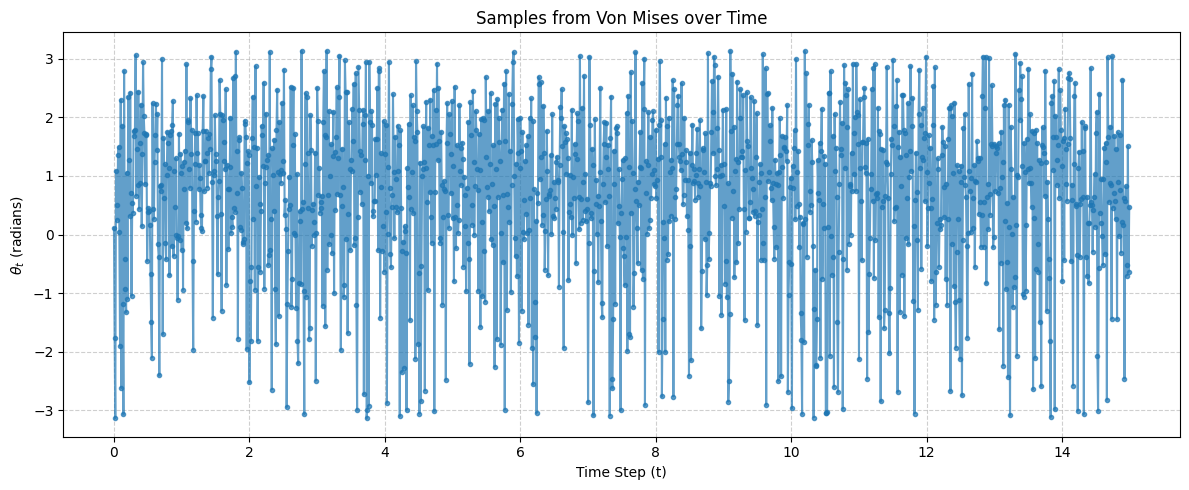

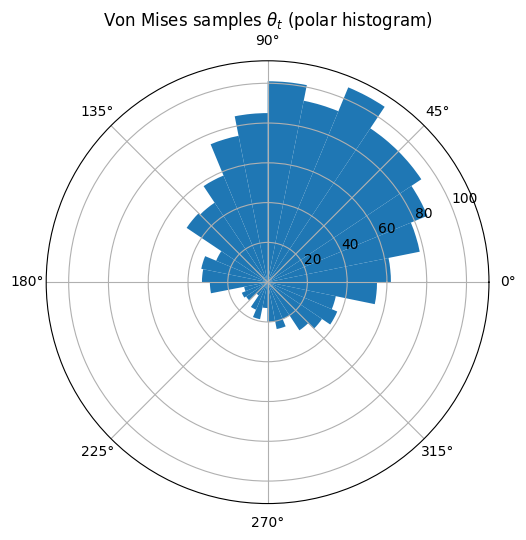

In [9]:
t, theta = simulate_vonmises_tseries(n_steps=T, mu=np.deg2rad(mu_deg), kappa=kappa, dt=dt, seed=theta_seed)

# visualize vonmises

plot_vomises_ts(t, theta)
plot_polar_hist(theta, bins=32)

### Gaussian process to get s(θ)

In [10]:
# GP/tuning
K=5
n_bins=256
length_scale=0.4
variance=1.0
# mean=-1.0
mean = 0.0
transform="softplus"
gp_seed= 2

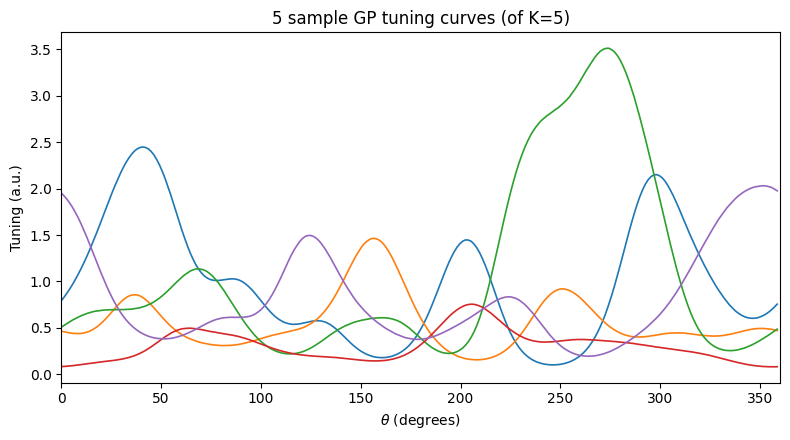

In [11]:
th_grid, S = sample_gp_tuning_functions(
        K=K, n_bins=n_bins, length_scale=length_scale, variance=variance,
        mean=mean, transform=transform, seed=gp_seed)

R = evaluate_tuning_at_angles(S, th_grid, theta) # (T, k)

plot_tuning_curves(th_grid, S, n_show=K)

### Adding OU process to the $s(\theta)$ to create drift

In [37]:
# ---------------------- OU drift for gains A_t ----------------------
def ou_drift(T, K, alpha=0.01, seed=None, A0=None, mode="signed"):
    """
    Vector OU/AR(1) per neuron:
        A_{t+1} = sqrt(1-α) * A_t + sqrt(α) * ξ_t,  ξ_t ~ N(0, I)
    Stationary Var = 1 in each dim; Corr(A_t, A_{t+Δ}) = (sqrt(1-α))^Δ.

    Args:
        T: time steps
        K: #neurons (dimensions)
        alpha: drift rate in (0,1]; larger => faster mean reversion (less temporal corr)
        seed: RNG seed
        A0: optional initial vector (K,)
        mode:
          "signed"   -> returns A_t as defined above (mean 0; can be ±)
          "positive" -> applies log-gain: returns exp(G_t - 0.5) so E[A]=1 (keeps activity ≥0)
    Returns:
        A: (T, K)
    """
    rng = np.random.default_rng(seed)
    rho = np.sqrt(1.0 - alpha)
    sig = np.sqrt(alpha)

    G = np.empty((T, K), dtype=float)
    G[0] = rng.standard_normal(K) if A0 is None else np.asarray(A0, float)
    for t in range(1, T):
        G[t] = rho * G[t-1] + sig * rng.standard_normal(K)

    if mode == "positive":
        # Convert to log-normal gains with mean ~1.0 (subtract 0.5 so E[exp(Z)] = 1 for Z~N(0,1))
        A = np.exp(G - 0.5)
    else:
        A = G
    return A

# ---- Visualize OU drift ----

def plot_ou_drift(t, A, alpha, mode):
    fig, ax = plt.subplots(figsize=(9, 3.6))
    for i in range(min(6, A.shape[1])):
        ax.plot(t, A[:, i], linewidth=1.0)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Gain A(t)")
    ax.set_title(f"OU drift (alpha={alpha}, mode='{mode}')")
    fig.tight_layout()
    plt.show()

# (c) lineplot of s(θ_t)
def plot_neurons_lineplot(t, R, ylabel="Neuron", title="R(t,i)"):
    """Plot neural responses in separate subplots with consistent y-axis.
    
    Args:
        t: time points
        R: array of shape (T, K) where K is number of neurons/signals
        ylabel: y-axis label base
        title: plot title
    """
    n_neurons = min(6, R.shape[1])  # Plot up to 6 neurons
    colors = plt.cm.tab10(np.linspace(0, 1, n_neurons))  # Get n_neurons distinct colors
    
    # Calculate global y-axis limits for consistency
    y_min = R[:, :n_neurons].min()
    y_max = R[:, :n_neurons].max()
    y_range = y_max - y_min
    y_limits = [y_min - 0.1*y_range, y_max + 0.1*y_range]
    
    # Create subplots with minimal spacing
    fig, axs = plt.subplots(n_neurons, 1, figsize=(9, n_neurons), sharex=True)
    fig.suptitle(title, y=0.95)
    
    # Plot each neuron in its own subplot
    lines = []  # Store lines for legend
    labels = []  # Store labels for legend
    
    for i in range(n_neurons):
        line = axs[i].plot(t, R[:, i], linewidth=1.0, color=colors[i])[0]
        lines.append(line)
        labels.append(f'{ylabel} {i+1}')
        
        axs[i].set_ylim(y_limits)
        # Remove all spines and ticks
        for spine in axs[i].spines.values():
            spine.set_visible(False)
        axs[i].tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
        
        # Add minimal y-label
        axs[i].text(-0.02, 0.5, f'{i+1}', transform=axs[i].transAxes,
                    verticalalignment='center', horizontalalignment='right')
    
    # Add single legend for all subplots
    fig.legend(lines, labels, loc='center right', bbox_to_anchor=(1.15, 0.5))
    
    # Set xlabel only on bottom subplot
    axs[-1].set_xlabel("Time (s)")
    
    # Adjust spacing
    plt.subplots_adjust(hspace=0.05, right=0.85)
    plt.show()


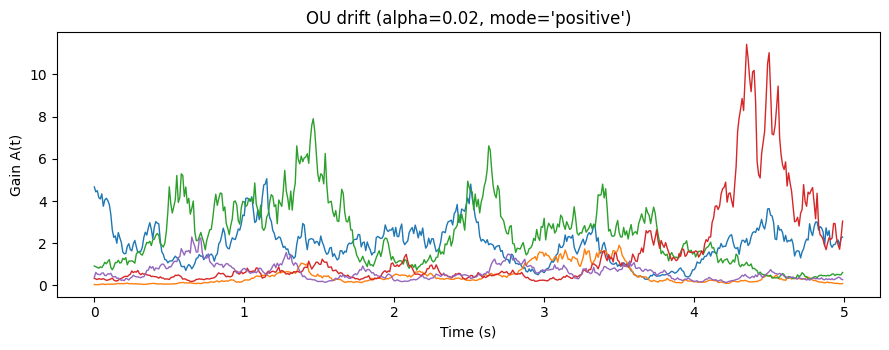

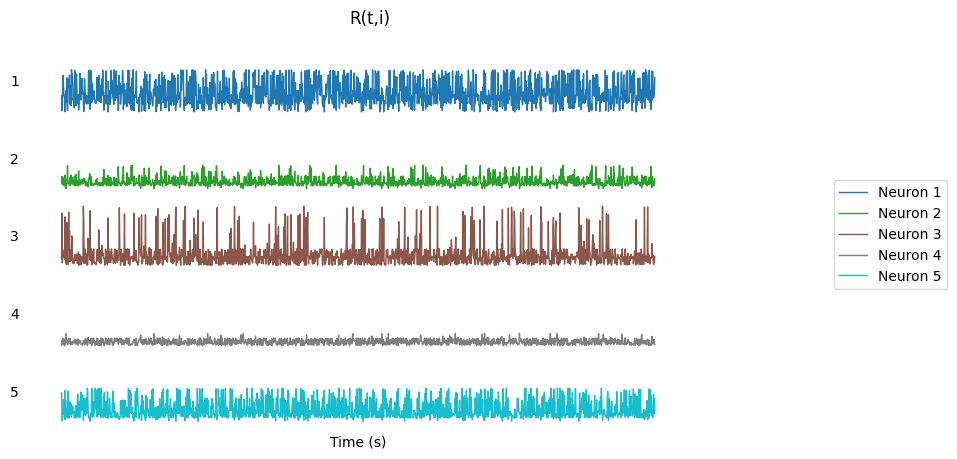

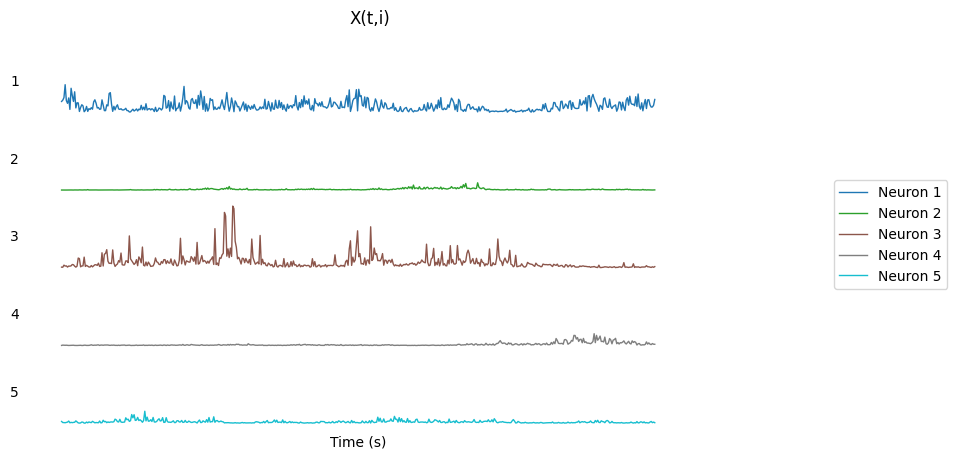

In [41]:
alpha = 0.02
ou_seed = 3

A = ou_drift(T=500, K=K, alpha=alpha, seed=ou_seed, mode="positive")

# X_t = A_t @ s(\theta_t)
X = A * R[T-500:T, :]

# visualization

plot_ou_drift(t[:500], A, alpha, mode="positive")
plot_neurons_lineplot(t, R)
plot_neurons_lineplot(t[T-500:T], X, title = "X(t,i)")


### PCA in the original space & drifted space

In [ ]:
# pca_theta_geometry.py
# PCA of R (T x K) and visualization of θ geometry in PC space.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from sklearn.decomposition import PCA

TAU = 2*np.pi

# ---------- PCA helpers ----------
def pca_on_R(R, n_components=5, center=True, zscore=False):
    """
    R : (T, K) stimulus-drive matrix (rows=time, cols=neurons)
    center : subtract per-neuron mean
    zscore : standardize per neuron (over time). If True, 'center' is implied.
    Returns:
        Z   : (T, n_components) PC scores
        pca : fitted sklearn PCA object (pca.components_, explained_variance_ratio_, ...)
        X0  : centered/scaled data used to fit (for reproducibility)
    """
    X = np.asarray(R, float)
    mu = X.mean(axis=0, keepdims=True)
    if zscore:
        sd = X.std(axis=0, keepdims=True) + 1e-9
        X0 = (X - mu) / sd
    elif center:
        X0 = X - mu
    else:
        X0 = X.copy()

    pca = PCA(n_components=n_components, svd_solver="full")
    Z = pca.fit_transform(X0)
    return Z, pca, X0

# ---------- Plotters ----------
def plot_pc2(Z, theta, title="PC1 vs PC2 colored by θ", cmap_name="hsv", s=8):
    th = (theta % TAU)
    norm = Normalize(vmin=0.0, vmax=TAU)
    cmap = get_cmap(cmap_name)
    colors = cmap(norm(th))

    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    ax.scatter(Z[:, 0], Z[:, 1], c=colors, s=s, edgecolors="none")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])

    # create colorbar tied to this Axes
    cbar = fig.colorbar(sm, ax=ax, ticks=np.linspace(0, TAU, 9))
    cbar.ax.set_yticklabels([f"{int(d)}°" for d in np.linspace(0, 360, 9)])
    cbar.set_label("θ")
    fig.tight_layout()

def plot_pc3(Z, theta, title="PC1–PC2–PC3 colored by θ", cmap_name="hsv", s=6):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    th = (theta % TAU)
    norm = Normalize(vmin=0.0, vmax=TAU)
    cmap = get_cmap(cmap_name)
    colors = cmap(norm(th))

    fig = plt.figure(figsize=(7.0, 6.0))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=colors, s=s, depthshade=False)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
    ax.set_title(title)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, ax=ax, pad=0.1, label="θ")
    fig.tight_layout()

# ---------- Optional: decode θ from top q PCs (sanity check) ----------
def decode_theta_from_pcs(Z, theta, q=2):
    """
    Fit a linear map from Z[:, :q] -> [sin θ, cos θ]; return decoded angles and R^2.
    """
    th = (theta % TAU)
    Y = np.column_stack([np.sin(th), np.cos(th)])  # (T,2)
    X = Z[:, :q]
    W, *_ = np.linalg.lstsq(X, Y, rcond=None)     # (q,2)
    Yhat = X @ W                                   # (T,2)
    th_hat = np.arctan2(Yhat[:, 0], Yhat[:, 1])    # atan2(sin, cos)

    # Compute coefficient of determination separately for sin and cos
    def r2(y, yhat):
        ss_res = np.sum((y - yhat)**2)
        ss_tot = np.sum((y - y.mean())**2) + 1e-12
        return 1 - ss_res/ss_tot
    r2_sin = r2(Y[:, 0], Yhat[:, 0])
    r2_cos = r2(Y[:, 1], Yhat[:, 1])
    return th_hat, (r2_sin, r2_cos)

# ---------- One-call convenience ----------
def visualize_theta_in_pca(R, theta, center=True, zscore=False, n_components=5,
                           do_pc3=True, do_decoder=True):
    """
    Run PCA on R and visualize θ in PC space.
    """
    Z, pca, X0 = pca_on_R(R, n_components=n_components, center=center, zscore=zscore)
    evr = pca.explained_variance_ratio_
    print(f"Explained variance ratio (first {n_components} PCs): {np.round(evr, 4)}")

    plot_pc2(Z, theta, title="PC1 vs PC2 colored by θ")
    if do_pc3 and n_components >= 3:
        plot_pc3(Z, theta, title="PC1–PC2–PC3 colored by θ")

    if do_decoder:
        th_hat, (r2_sin, r2_cos) = decode_theta_from_pcs(Z, theta, q=min(2, n_components))
        err_deg = np.rad2deg(np.angle(np.exp(1j*(theta - th_hat))))  # wrapped error in degrees
        print(f"Linear decode from top-2 PCs → R²(sin)={r2_sin:.3f}, R²(cos)={r2_cos:.3f}")
        plt.figure(figsize=(6.2, 3.6))
        plt.plot(err_deg, linewidth=0.9)
        plt.xlabel("Time"); plt.ylabel("Angle error (deg)")
        plt.title("θ decoding error (top-2 PCs → sin/cos)")
        plt.tight_layout()

    plt.show()
    return Z, pca

# --------------------------------------------------------------------
# Demo wiring (optional): create R, θ_t like earlier if you want to run this file standalone
# --------------------------------------------------------------------
if __name__ == "__main__":
    # --- minimal generator for R and theta_t (matches our earlier setup) ---
    # GP tuning on the circle
    def periodic_rbf_kernel(th1, th2, length_scale=0.4, variance=1.0):
        d = th1[:, None] - th2[None, :]
        return variance * np.exp(-2.0 * (np.sin(d/2.0)**2) / (length_scale**2))
    def theta_grid(n_bins=256): return np.linspace(0.0, TAU, n_bins, endpoint=False)
    def sample_gp_tuning(K=30, n_bins=256, length_scale=0.4, variance=1.0, mean=-1.0,
                         transform="softplus", seed=0):
        rng = np.random.default_rng(seed)
        thg = theta_grid(n_bins)
        Kxx = periodic_rbf_kernel(thg, thg, length_scale, variance)
        L = np.linalg.cholesky(Kxx + 1e-6*np.eye(n_bins))
        F = L @ rng.standard_normal((n_bins, K)) + mean
        if transform == "softplus": S = np.log1p(np.exp(F))
        elif transform == "exp":   S = np.exp(F)
        elif transform == "relu":  S = np.maximum(F, 0.0)
        else:                      S = F
        return thg, S.T
    def evaluate_on_angles(S, th_grid, theta_t):
        M = th_grid.size
        x = (theta_t % TAU) / (TAU/M)
        i0 = np.floor(x).astype(int) % M
        i1 = (i0 + 1) % M
        w  = x - np.floor(x)
        return (1-w)[:, None]*S[:, i0].T + w[:, None]*S[:, i1].T

    # make data
    rng = np.random.default_rng(1)
    K, T = 30, 1500
    th_grid, S = sample_gp_tuning(K=K, seed=0)
    # von Mises path
    mu, kappa = np.deg2rad(60.0), 6.0
    theta_t = rng.vonmises(mu, kappa, size=T)
    R = evaluate_on_angles(S, th_grid, theta_t)   # (T, K)

    # visualize
    visualize_theta_in_pca(R, theta_t, center=True, zscore=False, n_components=5,
                           do_pc3=True, do_decoder=True)

### After-drift geometry in PC space

In [ ]:
# project_X_in_R_pc_space.py
# Fit PCA on R, project X into the same PC space, and visualize X (colored by θ).

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from sklearn.decomposition import PCA

TAU = 2*np.pi

# ----------------------------- PCA utils -----------------------------
def fit_pca_on_R(R, n_components=5, zscore=False):
    """
    Fit PCA on R with a frozen preprocessing pipeline.
    Returns:
      pca: sklearn PCA fitted on preprocessed R
      prep: dict with {'mu','sd','zscore'} to reapply on any new matrix before transform
      Z_R: PC scores of R (T x n_components)
    """
    R = np.asarray(R, float)
    mu = R.mean(axis=0, keepdims=True)
    if zscore:
        sd = R.std(axis=0, keepdims=True) + 1e-9
    else:
        sd = np.ones_like(mu)

    R0 = (R - mu) / sd
    pca = PCA(n_components=n_components, svd_solver="full")
    Z_R = pca.fit_transform(R0)
    prep = {"mu": mu, "sd": sd, "zscore": zscore}
    return pca, prep, Z_R

def project_with_R_pca(X, pca, prep):
    """
    Project X into the PC space defined by R (same centering/scaling and PCA).
    """
    X0 = (np.asarray(X, float) - prep["mu"]) / prep["sd"]
    # Use pca.transform so we also subtract pca.mean_ (≈0 since R0 was centered)
    return pca.transform(X0)   # (T, n_components)

# ----------------------------- Plotters ------------------------------
# --- add/replace these plotters ---

from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
TAU = 2*np.pi

def _theta_colors(theta, cmap_name="hsv"):
    th = (theta % TAU)
    return get_cmap(cmap_name)(Normalize(0.0, TAU)(th))

def plot_pc12_overlay(Z_R, Z_X, theta_X, title="PC1–PC2: X (colored by θ) + R (black ×)",
                      s_x=10, s_r=22, cmap_name="hsv"):
    colors = _theta_colors(theta_X, cmap_name)
    fig, ax = plt.subplots(figsize=(6.6, 5.4))
    # X: colored points
    ax.scatter(Z_X[:, 0], Z_X[:, 1], c=colors[:1500], s=s_x, edgecolors="none", label="X")
    # R: black * markers
    ax.scatter(Z_R[:, 0], Z_R[:, 1], c="k", s=s_r, marker="*", linewidths=0.9, alpha=0.95, label="R")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title)

    sm = plt.cm.ScalarMappable(norm=Normalize(0, TAU), cmap=get_cmap(cmap_name))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, ticks=np.linspace(0, TAU, 9), fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels([f"{int(d)}°" for d in np.linspace(0, 360, 9)])
    cbar.set_label("θ (for X)")

    # Optional legend (R shown as black *)
    ax.legend(loc="best", frameon=False)
    fig.tight_layout()
    return fig, ax

def plot_pc123_overlay(Z_R, Z_X, theta_X, title="PC1–PC2–PC3: X (colored by θ) + R (black *)",
                       s_x=8, s_r=28, cmap_name="hsv"):
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    colors = _theta_colors(theta_X, cmap_name)
    fig = plt.figure(figsize=(7.2, 6.2))
    ax = fig.add_subplot(111, projection="3d")

    # X: colored points
    ax.scatter(Z_X[:, 0], Z_X[:, 1], Z_X[:, 2], c=colors[:1500], s=s_x, depthshade=False, label="X")
    # R: black * markers
    ax.scatter(Z_R[:, 0], Z_R[:, 1], Z_R[:, 2], c="k", marker="*",
               s=s_r, depthshade=False, linewidths=0.9, alpha=0.95, label="R")

    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
    ax.set_title(title)

    sm = plt.cm.ScalarMappable(norm=Normalize(0, TAU), cmap=get_cmap(cmap_name))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, pad=0.10, label="θ (for X)")

    # Optional legend
    ax.legend(loc="upper left")
    fig.tight_layout()
    return fig, ax

# ---------------------- Demo wiring (optional) -----------------------
# Minimal GP tuning + von Mises + OU drift to synthesize R and X.

def periodic_rbf_kernel(th1, th2, length_scale=0.4, variance=1.0):
    d = th1[:, None] - th2[None, :]
    return variance * np.exp(-2.0 * (np.sin(d/2.0)**2) / (length_scale**2))

def theta_grid(n_bins=256):
    return np.linspace(0.0, TAU, n_bins, endpoint=False)

def sample_gp_tuning_functions(K=30, n_bins=256, length_scale=0.4, variance=1.0,
                               mean=-1.0, transform="softplus", seed=0):
    rng = np.random.default_rng(seed)
    thg = theta_grid(n_bins)
    Kxx = periodic_rbf_kernel(thg, thg, length_scale, variance)
    L = np.linalg.cholesky(Kxx + 1e-6*np.eye(n_bins))
    F = L @ rng.standard_normal((n_bins, K)) + mean
    if transform == "softplus": S = np.log1p(np.exp(F))
    elif transform == "exp":   S = np.exp(F)
    elif transform == "relu":  S = np.maximum(F, 0.0)
    else:                      S = F
    return thg, S.T

def evaluate_tuning_at_angles(S, th_grid, theta_t):
    M = th_grid.size
    dtheta = TAU / M
    x = (theta_t % TAU) / dtheta
    i0 = np.floor(x).astype(int) % M
    i1 = (i0 + 1) % M
    w  = x - np.floor(x)
    return (1-w)[:, None]*S[:, i0].T + w[:, None]*S[:, i1].T  # (T,K)

def simulate_vonmises_tseries(T, mu, kappa, seed=1):
    rng = np.random.default_rng(seed)
    return rng.vonmises(mu, kappa, size=T)

def ou_gains(T, K, alpha=0.02, seed=2, positive=True):
    rng = np.random.default_rng(seed)
    rho = np.sqrt(1 - alpha); sig = np.sqrt(alpha)
    G = np.empty((T, K)); G[0] = rng.standard_normal(K)
    for t in range(1, T):
        G[t] = rho*G[t-1] + sig*rng.standard_normal(K)
    return np.exp(G - 0.5) if positive else G   # positive multiplicative gains (E≈1)

# ------------------------------- Main --------------------------------
def visualize_X_in_R_pc_space(
    # data (optional; if None, demo will synthesize them)
    R=None, theta=None, X=None, theta_X=None,
    # PCA & viz
    n_components=5, zscore=False, cmap_name="hsv"
):
    """
    Fit PCA on R, project X with the same pipeline, and visualize X in R's PC space.
    If R/theta/X/theta_X are None, a demo dataset is generated.
    """
    # --- synthesize if needed ---
    if R is None or theta is None or X is None or theta_X is None:
        K, T = 30, 3000
        th_grid, S = sample_gp_tuning_functions(K=K, seed=0)
        mu, kappa = np.deg2rad(60.0), 6.0
        theta = simulate_vonmises_tseries(T, mu, kappa, seed=1)
        R = evaluate_tuning_at_angles(S, th_grid, theta)  # (T,K)
        A = ou_gains(T, K, alpha=0.02, seed=2, positive=True)
        X = A * R
        # slice X to the last 1500 steps
        X = X[T//2:, :]
        theta_X = theta  # same angles

    # --- Fit PCA on R and project X using same preprocessing ---
    pca, prep, Z_R = fit_pca_on_R(R, n_components=n_components, zscore=zscore)
    Z_X = project_with_R_pca(X, pca, prep)

    # --- Visualize X in R's PC space ---
# new (overlay X & R):
    plot_pc12_overlay(Z_R, Z_X, theta_X,
                  title="X in R-PC space (PC1–PC2): X colored by θ; R as black *")
    if n_components >= 3:
        plot_pc123_overlay(Z_R, Z_X, theta_X,
                       title="X in R-PC space (PC1–PC2–PC3): X colored by θ; R as black *")
    plt.show()

    return {"Z_R": Z_R, "Z_X": Z_X, "pca": pca, "prep": prep}

# ----------------------------- Entry point ---------------------------
if __name__ == "__main__":
    visualize_X_in_R_pc_space(
        R=None, theta=None, X=None, theta_X=None,   # set your arrays here to bypass the demo
        n_components=5,
        zscore=False,        # set True to standardize per neuron before PCA (applied to both R and X)
        cmap_name="hsv"      # 'hsv' matches your examples; try 'twilight' for a cyclic, smoother map
    )

### X in their original PC space